In [26]:
!pip install yfinance
!mkdir -p data

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import yfinance as yf

# Set random seed for reproducibility for consistent results
np.random.seed(42)

In [35]:
stock_names = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'INTC']
n_stocks = len(stock_names)
start_date = '2025-01-01'
end_date = '2026-01-01'

tickers = yf.download(stock_names, start=start_date, end=end_date, progress=False) # Suppress progress bar
adj_close_prices = tickers['Close']

display(adj_close_prices.describe())

/tmp/ipython-input-2677013141.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tickers = yf.download(stock_names, start=start_date, end=end_date, progress=False) # Suppress progress bar


Ticker,AAPL,AMZN,GOOGL,INTC,META,MSFT,NVDA,TSLA
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,231.779716,217.672800,210.531562,26.259120,668.401281,462.829344,153.883274,356.970760
std,26.624365,17.096192,51.443769,7.292031,68.742673,51.023600,29.772027,69.977317
min,171.832413,167.320007,144.301498,18.129999,483.566345,352.669373,94.292885,221.860001
25%,209.571266,208.022503,170.131012,20.552499,617.818222,413.059036,129.829971,308.614990
50%,229.652374,222.120003,192.015106,23.170000,666.903290,478.558060,158.772209,344.044998
75%,254.086185,229.634998,246.828548,34.495000,719.235031,507.380379,180.389824,425.857491
max,286.190002,254.000000,323.228577,43.759998,788.823792,541.057373,207.028473,489.880005


In [36]:
df_returns = adj_close_prices.pct_change().dropna()
print("Daily Return statistics:")
display(df_returns.describe())

Daily Return statistics:


Ticker,AAPL,AMZN,GOOGL,INTC,META,MSFT,NVDA,TSLA
count,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000
mean,0.000661,0.000422,0.002241,0.003201,0.000684,0.000725,0.001692,0.001471
std,0.020450,0.021726,0.020417,0.040349,0.023954,0.015307,0.031268,0.039880
min,-0.092456,-0.089791,-0.072924,-0.115025,-0.113348,-0.061809,-0.169682,-0.154262
25%,-0.006692,-0.011164,-0.008526,-0.016974,-0.011604,-0.006116,-0.011594,-0.021034
50%,0.000786,0.000602,0.001641,-0.001634,0.000966,0.000780,0.002648,0.000342
75%,0.006577,0.012418,0.013704,0.020186,0.012016,0.006139,0.018296,0.024384
max,0.153289,0.119770,0.096821,0.227711,0.147556,0.101337,0.187227,0.226900


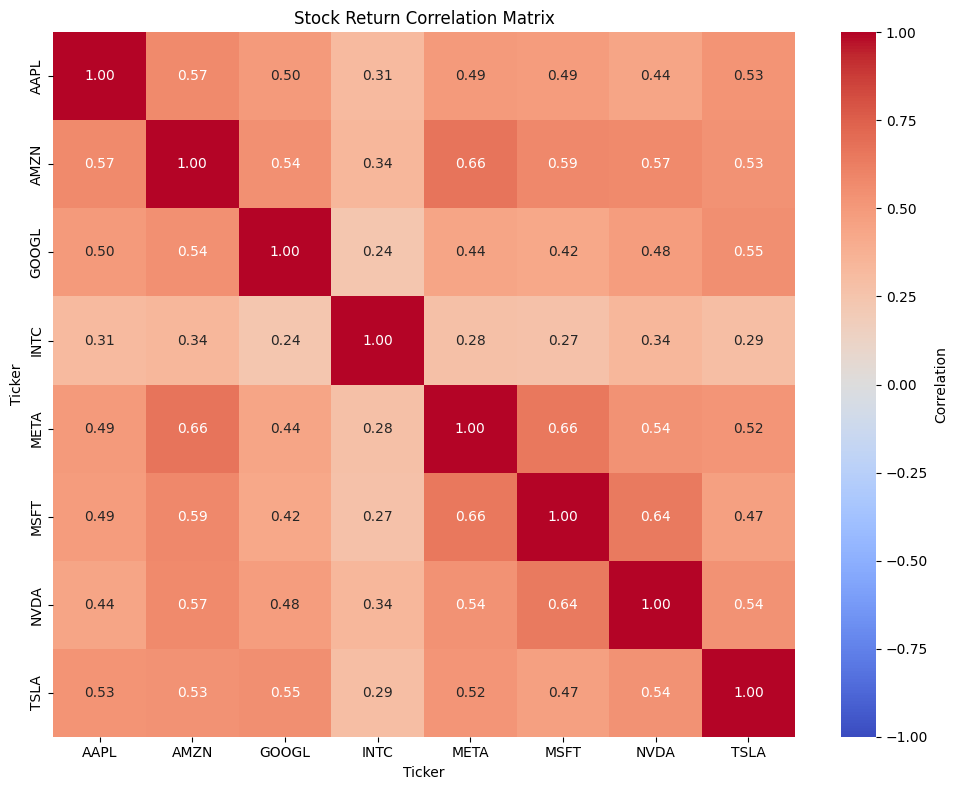

In [38]:
correlation_matrix = df_returns.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Stock Return Correlation Matrix')
plt.tight_layout()

# use networkx to create a correlation graph

In [30]:
def build_correlation_graph(corr_matrix, threshold=0.3):
    G = nx.Graph()
    for stock in corr_matrix.columns:
        G.add_node(stock)
    edge_list = []
    for i, stock1 in enumerate(corr_matrix.columns):
        for j, stock2 in enumerate(corr_matrix.columns):
            if i < j:  # Avoid self-loops and duplicate edges
                corr_value = corr_matrix.iloc[i, j]
                if abs(corr_value) > threshold:
                    G.add_edge(stock1, stock2, weight=abs(corr_value))
                    edge_list.append((stock1, stock2, corr_value))

    return G, edge_list

thresholds = [0.3, 0.5, 0.7]
graphs = {}

for threshold in thresholds:
    G, _ = build_correlation_graph(correlation_matrix, threshold)
    graphs[threshold] = G

    print(f"\n--- Threshold: {threshold} ---")
    print(f"Nodes: {G.number_of_nodes()}")
    print(f"Edges: {G.number_of_edges()}")
    if G.number_of_nodes() > 0:
        print(f"Average degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")
    else:
        print("Average degree: 0.00")
    print(f"Density: {nx.density(G):.3f}")
    if G.number_of_edges() > 0:
        print(f"Average edge weight: {np.mean([G[u][v]['weight'] for u, v in G.edges()]):.3f}")

Building Financial Graphs from Correlations with different thresholds:

--- Threshold: 0.3 ---
Nodes: 8
Edges: 28
Average degree: 7.00
Density: 1.000
Average edge weight: 0.663

--- Threshold: 0.5 ---
Nodes: 8
Edges: 26
Average degree: 6.50
Density: 0.929
Average edge weight: 0.680

--- Threshold: 0.7 ---
Nodes: 8
Edges: 11
Average degree: 2.75
Density: 0.393
Average edge weight: 0.766


The paper notes that changing correlation threshold from 0.3 to 0.5 swings AUC by 2-5% in prediction models.

Here we see why:
- **Threshold 0.3**: More edges, captures weak relationships (potentially noisier)
- **Threshold 0.5**: Fewer edges, captures strong relationships (less noise, but might miss subtle connections)
- **Threshold 0.7**: Very selective, only strongest relationships

This sensitivity means models may OVERFIT to graph structure choice! This highlights the importance of carefully selecting the threshold or using more advanced methods to determine graph connectivity.

## visualizing graph

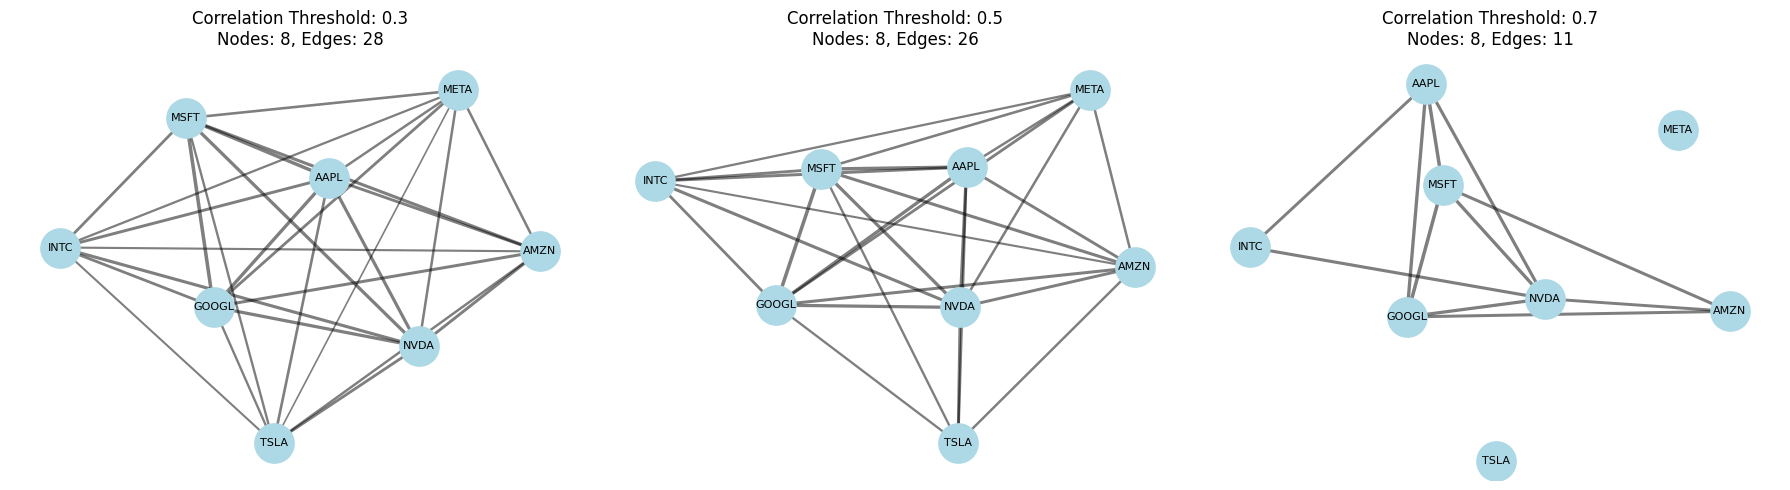

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, threshold in enumerate(thresholds):
    ax = axes[idx]
    G = graphs[threshold]

    # Create layout for visualization
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

    # Draw network nodes and labels
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

    # Draw edges with varying thickness based on weight
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]

    nx.draw_networkx_edges(G, pos, width=[w*3 for w in weights], alpha=0.5, ax=ax)

    ax.set_title(f'Correlation Threshold: {threshold}\nNodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')
    ax.axis('off')

plt.tight_layout()

getting optimal threshold

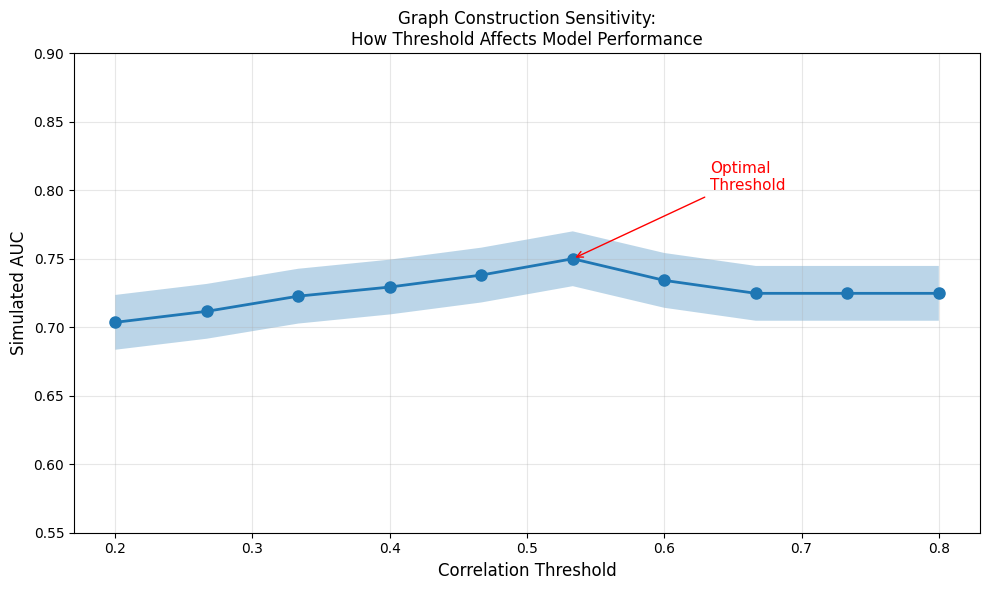

In [45]:
thresholds_range = np.linspace(0.2, 0.8, 10)
simulated_auc = []

for threshold in thresholds_range:
    G, _ = build_correlation_graph(correlation_matrix, threshold)
    n_edges = G.number_of_edges()
    density = nx.density(G)

    auc = 0.75 - 0.1 * abs(density - 0.4)**1.5
    auc = np.clip(auc, 0.6, 0.85) # Ensure AUC stays within reasonable bounds
    simulated_auc.append(auc)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_range, simulated_auc, 'o-', linewidth=2, markersize=8)
ax.fill_between(thresholds_range, np.array(simulated_auc) - 0.02,
                np.array(simulated_auc) + 0.02, alpha=0.3)
ax.set_xlabel('Correlation Threshold', fontsize=12)
ax.set_ylabel('Simulated AUC', fontsize=12)
ax.set_title('Graph Construction Sensitivity:\nHow Threshold Affects Model Performance')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.55, 0.9)

opt_idx = np.argmax(simulated_auc)
ax.annotate('Optimal\nThreshold', xy=(thresholds_range[opt_idx], simulated_auc[opt_idx]),
            xytext=(thresholds_range[opt_idx] + 0.1, simulated_auc[opt_idx] + 0.05),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')

plt.tight_layout()

## data structures for graph

### Adjacency matrix

In [39]:
G_default = graphs[0.3]

stock_to_idx = {stock: i for i, stock in enumerate(stock_names)}
adj_matrix = np.zeros((n_stocks, n_stocks))
for u, v, data in G_default.edges(data=True):
    idx1 = stock_to_idx[u]
    idx2 = stock_to_idx[v]
    adj_matrix[idx1, idx2] = data['weight']
    adj_matrix[idx2, idx1] = data['weight']
display(pd.DataFrame(adj_matrix, index=stock_names, columns=stock_names).round(3))

,AAPL,MSFT,GOOGL,AMZN,TSLA,META,NVDA,INTC
AAPL,0.000,0.825,0.798,0.696,0.637,0.593,0.763,0.709
MSFT,0.825,0.000,0.850,0.741,0.564,0.626,0.788,0.668
GOOGL,0.798,0.850,0.000,0.722,0.562,0.680,0.772,0.672
AMZN,0.696,0.741,0.722,0.000,0.592,0.606,0.709,0.511
TSLA,0.637,0.564,0.562,0.592,0.000,0.399,0.680,0.497
META,0.593,0.626,0.680,0.606,0.399,0.000,0.608,0.547
NVDA,0.763,0.788,0.772,0.709,0.680,0.608,0.000,0.749
INTC,0.709,0.668,0.672,0.511,0.497,0.547,0.749,0.000


### node features

In [40]:
X = np.random.randn(n_stocks, 5)  # 5 features per node
X_df = pd.DataFrame(X, index=stock_names,
                   columns=['Price', 'Momentum', 'Volatility', 'PE_Ratio', 'Sector_Encoded'])
display(X_df.round(3))

,Price,Momentum,Volatility,PE_Ratio,Sector_Encoded
AAPL,0.738,0.171,-0.116,-0.301,-1.479
MSFT,-0.720,-0.461,1.057,0.344,-1.763
GOOGL,0.324,-0.385,-0.677,0.612,1.031
AMZN,0.931,-0.839,-0.309,0.331,0.976
TSLA,-0.479,-0.186,-1.106,-1.196,0.813
META,1.356,-0.072,1.004,0.362,-0.645
NVDA,0.361,1.538,-0.036,1.565,-2.620
INTC,0.822,0.087,-0.299,0.092,-1.988


### Edge List

In [43]:
edge_list = [(stock_to_idx[u], stock_to_idx[v])
             for u, v in G_default.edges()]
print(edge_list)

[(0, 3), (0, 2), (0, 7), (0, 5), (0, 1), (0, 6), (0, 4), (3, 2), (3, 7), (3, 5), (3, 1), (3, 6), (3, 4), (2, 7), (2, 5), (2, 1), (2, 6), (2, 4), (7, 5), (7, 1), (7, 6), (7, 4), (5, 1), (5, 6), (5, 4), (1, 6), (1, 4), (6, 4)]
